# Load Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle as pickle
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn import svm
from sklearn.metrics import matthews_corrcoef, make_scorer, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

from classical_data_processing import get_vectorized_data

# Import Data

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = get_vectorized_data()

In [3]:
class_names = pd.read_csv("../data/class_names.csv", index_col=0).to_numpy()
class_names

array([['Irrelevant'],
       ['Negative'],
       ['Neutral'],
       ['Positive']], dtype=object)

In [4]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [5]:
X_val

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# Model

In [7]:
svc = svm.LinearSVC(random_state=42)
matthews_scorer = make_scorer(matthews_corrcoef)

## Hyperparameter Search

In [8]:
param_grid = {
    "loss": ["hinge", "squared_hinge"],
    "dual": [True, False],
    "C": [0.01, 0.1, 0.5, 1.0],
    "max_iter": [500, 1000, 2000, 5000, 10000, 20000]
}

grid_search = GridSearchCV(svc, param_grid, scoring=matthews_scorer, verbose=3)
grid_search.fit(X_train, y_train)

grid_search.cv_results_

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV 1/5] END C=0.01, dual=True, loss=hinge, max_iter=500;, score=0.428 total time=   0.9s
[CV 2/5] END C=0.01, dual=True, loss=hinge, max_iter=500;, score=0.429 total time=   0.9s
[CV 3/5] END C=0.01, dual=True, loss=hinge, max_iter=500;, score=0.422 total time=   0.9s
[CV 4/5] END C=0.01, dual=True, loss=hinge, max_iter=500;, score=0.437 total time=   0.8s
[CV 5/5] END C=0.01, dual=True, loss=hinge, max_iter=500;, score=0.428 total time=   0.8s
[CV 1/5] END C=0.01, dual=True, loss=hinge, max_iter=1000;, score=0.428 total time=   0.9s
[CV 2/5] END C=0.01, dual=True, loss=hinge, max_iter=1000;, score=0.429 total time=   0.8s
[CV 3/5] END C=0.01, dual=True, loss=hinge, max_iter=1000;, score=0.422 total time=   0.8s
[CV 4/5] END C=0.01, dual=True, loss=hinge, max_iter=1000;, score=0.437 total time=   0.8s
[CV 5/5] END C=0.01, dual=True, loss=hinge, max_iter=1000;, score=0.428 total time=   0.8s
[CV 1/5] END C=0.01, dual=True, l

F:\Tyler\Documents\College, Part 2\CSCI-635\csci-635-project\.venv\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV 1/5] END C=0.1, dual=True, loss=hinge, max_iter=500;, score=0.468 total time=   1.5s


F:\Tyler\Documents\College, Part 2\CSCI-635\csci-635-project\.venv\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV 2/5] END C=0.1, dual=True, loss=hinge, max_iter=500;, score=0.467 total time=   1.2s


...

[CV 5/5] END C=1.0, dual=True, loss=hinge, max_iter=10000;, score=0.497 total time=   6.1s
[CV 1/5] END C=1.0, dual=True, loss=hinge, max_iter=20000;, score=0.488 total time=   7.4s
[CV 2/5] END C=1.0, dual=True, loss=hinge, max_iter=20000;, score=0.488 total time=   9.6s


F:\Tyler\Documents\College, Part 2\CSCI-635\csci-635-project\.venv\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV 3/5] END C=1.0, dual=True, loss=hinge, max_iter=20000;, score=0.482 total time=   8.0s
[CV 4/5] END C=1.0, dual=True, loss=hinge, max_iter=20000;, score=0.491 total time=   6.8s
[CV 5/5] END C=1.0, dual=True, loss=hinge, max_iter=20000;, score=0.497 total time=   7.1s
[CV 1/5] END C=1.0, dual=True, loss=squared_hinge, max_iter=500;, score=0.484 total time=   3.8s
[CV 2/5] END C=1.0, dual=True, loss=squared_hinge, max_iter=500;, score=0.485 total time=   3.9s
[CV 3/5] END C=1.0, dual=True, loss=squared_hinge, max_iter=500;, score=0.480 total time=   3.8s
[CV 4/5] END C=1.0, dual=True, loss=squared_hinge, max_iter=500;, score=0.489 total time=   4.0s
[CV 5/5] END C=1.0, dual=True, loss=squared_hinge, max_iter=500;, score=0.497 total time=   4.4s
[CV 1/5] END C=1.0, dual=True, loss=squared_hinge, max_iter=1000;, score=0.484 total time=   3.9s
[CV 2/5] END C=1.0, dual=True, loss=squared_hinge, max_iter=1000;, score=0.485 total time=   4.0s
[CV 3/5] END C=1.0, dual=True, loss=squared_hi

F:\Tyler\Documents\College, Part 2\CSCI-635\csci-635-project\.venv\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "F:\Tyler\Documents\College, Part 2\CSCI-635\csci-635-project\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "F:\Tyler\Documents\College, Part 2\CSCI-635\csci-635-project\.venv\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "F:\Tyler\Documents\College, Part

{'mean_fit_time': array([0.92306538, 0.87025037, 0.91195025, 0.91701903, 0.89496274,
        0.88834643, 1.07614622, 1.08222475, 1.0706543 , 1.07228751,
        1.07240601, 1.05712614, 0.25162196, 0.27692509, 0.26425009,
        0.24706511, 0.28531823, 0.27230787, 2.00090508, 1.89469409,
        2.11686292, 1.87570672, 1.88755803, 2.13620839, 1.37533937,
        1.48142066, 2.00634441, 1.7076561 , 1.6624495 , 1.59734564,
        1.5250926 , 1.51624136, 1.52999558, 1.56642752, 1.51774559,
        1.5282618 , 0.33572059, 0.30031734, 0.29003677, 0.32112575,
        0.33031254, 0.31506772, 3.53202686, 3.82535501, 3.53731642,
        3.41973386, 3.44755445, 3.46889644, 1.77779932, 2.09352231,
        2.65587864, 4.51401277, 4.92042112, 4.73014102, 2.68809123,
        2.71506596, 2.61489267, 2.55872202, 2.57904401, 2.54955564,
        0.24379067, 0.2514617 , 0.26442666, 0.28165812, 0.49772754,
        0.4301662 , 4.41250806, 3.9622674 , 4.09358997, 4.07823544,
        4.01880264, 4.00340028,

In [9]:
best_model = grid_search.best_estimator_

## Training Evaluation

In [10]:
train_score = best_model.score(X_train, y_train)

print("Training Score: ", train_score)

Training Score:  0.6345152746700763


## Validation

In [11]:
val_score = best_model.score(X_val, y_val)

print("Validation Score: ", val_score)

Validation Score:  0.6073333333333333


## Test Evaluation

In [12]:
test_score = best_model.score(X_test, y_test)

print("Test Score: ", test_score)

Test Score:  0.67


# Display Results

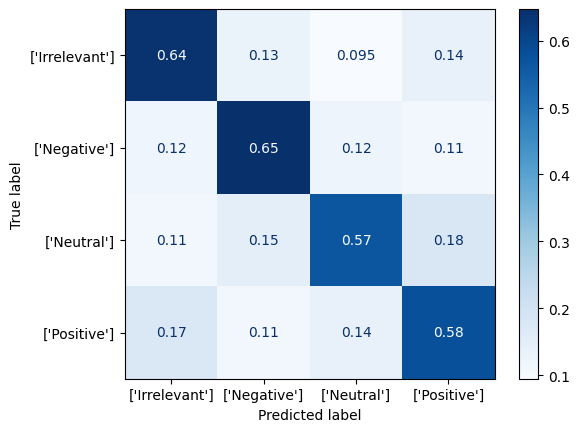

In [17]:
titles = [
    ("Confusion Matrix (without normalization)", None),
    ("Confusion Matrix (normalized)", "true")
]

display = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_val,
    y_val,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize="true"
)

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_pred = best_model.predict(X_test)

In [49]:
# MCC
matthews_corrcoef(y_test, y_pred)

np.float64(0.5581436856846996)

In [46]:
# PRECISION
precision_score(y_test, y_pred, average="macro")

0.6634492908207681

In [47]:
# RECALL
recall_score(y_test, y_pred, average="macro")

0.6694575805435845

In [48]:
# F1 SCORE
f1_score(y_test, y_pred, average="macro")

0.6646804950319152